<a href="https://colab.research.google.com/github/danhhuit/image-captioning-distillation/blob/main/Tuan03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
sabahesaraki_2017_2017_path = kagglehub.dataset_download('sabahesaraki/2017-2017')

print('Data source import complete.')


## 1. Cài đặt thư viện

In [ ]:
%pip install -q kagglehub pycocotools pycocoevalcap rouge-score ftfy regex tqdm
%pip install -q git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 16.4 MB/s eta 0:00:0000:010:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
  Preparing metadata (setup.py) ... done
Note: you may need to restart the kernel to use updated packages.


# 2. Import, seed và GPU

In [ ]:
import os
import re
import gc
import json
import time
import random
import hashlib
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision.models import (
    resnet50, ResNet50_Weights,
    efficientnet_b3, EfficientNet_B3_Weights,
    vit_b_16, ViT_B_16_Weights,
)

import clip
import nltk
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
from pycocoevalcap.cider.cider import Cider

nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = DEVICE.type == "cuda"

print("PyTorch:", torch.__version__)
print("TorchVision:", torchvision.__version__)
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM (GB):", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2))

PyTorch: 2.10.0+cu128
TorchVision: 0.25.0+cu128
Device: cuda
GPU: Tesla T4
VRAM (GB): 14.56


# 3. Cấu hình thí nghiệm

Giữ cấu hình chính của tuần 2:
- `MIN_FREQ=5`, `MAX_LEN=30`
- `d_model=256`, `nhead=8`, `num_layers=3`
- `dim_feedforward=1024`, `dropout=0.1`
- `max_epochs=20`, `learning_rate=3e-4`
- early stopping patience = 4
- Beam Search = 3

**Không giới hạn số ảnh train.**

In [ ]:
KAGGLE_DATASET_HANDLE = "sabahesaraki/2017-2017"
DATA_ROOT_OVERRIDE = None

USE_FULL_DATASET = True
MAX_TRAIN_IMAGES = None
MAX_VAL_IMAGES = None
MAX_TEST_IMAGES = None

VAL_FRACTION_OF_COCO_VAL = 0.50

PAD_TOKEN = "<pad>"
BOS_TOKEN = "<bos>"
EOS_TOKEN = "<eos>"
UNK_TOKEN = "<unk>"

MIN_FREQ = 5
MAX_LEN = 30

D_MODEL = 256
NHEAD = 8
NUM_LAYERS = 3
DIM_FEEDFORWARD = 1024
DROPOUT = 0.1

FEATURE_BATCH_SIZE = 64
CAPTION_BATCH_SIZE = 64

MAX_EPOCHS = 20
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
EARLY_STOPPING_PATIENCE = 4
GRAD_CLIP_NORM = 0.5

AMP_EXTRACT_ENABLED = DEVICE.type == "cuda"
AMP_TRAIN_ENABLED = False

DECODING_METHOD = "beam"
BEAM_SIZE = 3
LENGTH_PENALTY_ALPHA = 0.7

MODEL_NAMES = [
    "resnet50",
    "efficientnet_b3",
    "vit_b_16",
    "clip_vit_b16",
]

MODEL_DISPLAY_NAMES = {
    "resnet50": "ResNet-50",
    "efficientnet_b3": "EfficientNet-B3",
    "vit_b_16": "ViT-B/16",
    "clip_vit_b16": "CLIP-ViT-B/16",
}

MODELS_TO_RUN = MODEL_NAMES.copy()
# MODELS_TO_RUN = ["resnet50"]
# MODELS_TO_RUN = [
#     "efficientnet_b3",
#     "vit_b_16",
#     "clip_vit_b16",
# ]
assert USE_FULL_DATASET is True
assert MAX_TRAIN_IMAGES is None
assert all(model in MODEL_NAMES for model in MODELS_TO_RUN)

print("MODELS_TO_RUN:", MODELS_TO_RUN)
print("USE_FULL_DATASET:", USE_FULL_DATASET)

MODELS_TO_RUN: ['resnet50', 'efficientnet_b3', 'vit_b_16', 'clip_vit_b16']
USE_FULL_DATASET: True


# 4. Thư mục lưu kết quả

In [ ]:
IS_COLAB = False
try:
    from google.colab import drive
    drive.mount("/content/drive")
    IS_COLAB = True
except Exception:
    pass

if IS_COLAB:
    OUTPUT_ROOT = Path("/content/drive/MyDrive/KLCN/Tuan03/NguyenThanhDanh")
    WORK_ROOT = Path("/content/MSCOCO_W3_WORK")
elif Path("/kaggle/working").exists():
    OUTPUT_ROOT = Path("/kaggle/working/MSCOCO_W3")
    WORK_ROOT = Path("/kaggle/working/MSCOCO_W3_WORK")
else:
    OUTPUT_ROOT = Path("./MSCOCO_W3_OUTPUT")
    WORK_ROOT = Path("./MSCOCO_W3_WORK")

CHECKPOINT_DIR = OUTPUT_ROOT / "checkpoints"
LOG_DIR = OUTPUT_ROOT / "logs"
PREDICTION_DIR = OUTPUT_ROOT / "predictions"
FIGURE_DIR = OUTPUT_ROOT / "figures"
REPORT_DIR = OUTPUT_ROOT / "report_ready"
FEATURE_DIR = WORK_ROOT / "feature_cache"
TOKEN_CACHE_DIR = WORK_ROOT / "token_cache"

for folder in [
    OUTPUT_ROOT, WORK_ROOT, CHECKPOINT_DIR, LOG_DIR,
    PREDICTION_DIR, FIGURE_DIR, REPORT_DIR,
    FEATURE_DIR, TOKEN_CACHE_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

DELETE_FEATURE_CACHE_AFTER_MODEL = True

print("OUTPUT_ROOT:", OUTPUT_ROOT)
print("WORK_ROOT:", WORK_ROOT)

OUTPUT_ROOT: /kaggle/working/MSCOCO_W3
WORK_ROOT: /kaggle/working/MSCOCO_W3_WORK


# 5. Chuẩn bị MS COCO 2017 từ Kaggle

Ưu tiên:
1. `/kaggle/input/2017-2017` nếu chạy Kaggle Notebook.
2. `DATA_ROOT_OVERRIDE` nếu chỉ định thủ công.
3. `kagglehub.dataset_download(...)` nếu chạy Colab/máy cá nhân.

Nếu bộ Kaggle không kèm caption annotation, cell tiếp theo tải annotation caption chính thức của COCO 2017; ảnh vẫn lấy từ bộ Kaggle.

In [ ]:
def first_existing_dir(root: Path, dirname: str):
    matches = [p for p in root.rglob(dirname) if p.is_dir()]
    if not matches:
        return None
    matches = sorted(matches, key=lambda p: len(list(p.glob("*.jpg"))), reverse=True)
    return matches[0]

def first_existing_file(root: Path, filename: str):
    matches = [p for p in root.rglob(filename) if p.is_file()]
    return matches[0] if matches else None

def resolve_dataset_root():
    if DATA_ROOT_OVERRIDE is not None:
        root = Path(DATA_ROOT_OVERRIDE)
        if not root.exists():
            raise FileNotFoundError(f"DATA_ROOT_OVERRIDE không tồn tại: {root}")
        return root

    kaggle_input = Path("/kaggle/input/2017-2017")
    if kaggle_input.exists():
        return kaggle_input

    import kagglehub
    return Path(kagglehub.dataset_download(KAGGLE_DATASET_HANDLE))

DATA_ROOT = resolve_dataset_root()
print("DATA_ROOT:", DATA_ROOT)

TRAIN_IMAGE_DIR = first_existing_dir(DATA_ROOT, "train2017")
VAL_IMAGE_DIR = first_existing_dir(DATA_ROOT, "val2017")
TRAIN_CAPTION_JSON = first_existing_file(DATA_ROOT, "captions_train2017.json")
VAL_CAPTION_JSON = first_existing_file(DATA_ROOT, "captions_val2017.json")

if TRAIN_IMAGE_DIR is None or VAL_IMAGE_DIR is None:
    raise FileNotFoundError(
        "Không tìm thấy train2017/val2017. Kiểm tra DATA_ROOT hoặc cấu trúc dataset."
    )

print("TRAIN_IMAGE_DIR:", TRAIN_IMAGE_DIR)
print("VAL_IMAGE_DIR:", VAL_IMAGE_DIR)
print("TRAIN_CAPTION_JSON:", TRAIN_CAPTION_JSON)
print("VAL_CAPTION_JSON:", VAL_CAPTION_JSON)

DATA_ROOT: /kaggle/input/datasets/sabahesaraki/2017-2017
TRAIN_IMAGE_DIR: /kaggle/input/datasets/sabahesaraki/2017-2017/train2017/train2017
VAL_IMAGE_DIR: /kaggle/input/datasets/sabahesaraki/2017-2017/val2017/val2017
TRAIN_CAPTION_JSON: /kaggle/input/datasets/sabahesaraki/2017-2017/annotations_trainval2017/annotations/captions_train2017.json
VAL_CAPTION_JSON: /kaggle/input/datasets/sabahesaraki/2017-2017/annotations_trainval2017/annotations/captions_val2017.json


In [ ]:
if TRAIN_CAPTION_JSON is None or VAL_CAPTION_JSON is None:
    import urllib.request
    import zipfile

    annotation_zip = WORK_ROOT / "annotations_trainval2017.zip"
    annotation_url = "http://images.cocodataset.org/annotations/annotations_trainval2017.zip"

    print("Không thấy caption annotation trong bộ Kaggle.")
    print("Đang tải annotation captions chính thức COCO 2017...")

    if not annotation_zip.exists():
        urllib.request.urlretrieve(annotation_url, annotation_zip)

    extract_dir = WORK_ROOT / "coco_annotations"
    extract_dir.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(annotation_zip, "r") as zf:
        zf.extractall(extract_dir)

    TRAIN_CAPTION_JSON = first_existing_file(extract_dir, "captions_train2017.json")
    VAL_CAPTION_JSON = first_existing_file(extract_dir, "captions_val2017.json")

if TRAIN_CAPTION_JSON is None or VAL_CAPTION_JSON is None:
    raise FileNotFoundError("Không tìm thấy captions_train2017.json / captions_val2017.json")

print("Caption train:", TRAIN_CAPTION_JSON)
print("Caption val:", VAL_CAPTION_JSON)

Caption train: /kaggle/input/datasets/sabahesaraki/2017-2017/annotations_trainval2017/annotations/captions_train2017.json
Caption val: /kaggle/input/datasets/sabahesaraki/2017-2017/annotations_trainval2017/annotations/captions_val2017.json


# 6. Đọc toàn bộ annotation và tạo split

In [ ]:
def load_coco_caption_json(json_path: Path):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    image_info = {
        int(img["id"]): img["file_name"]
        for img in data["images"]
    }

    captions_by_image = defaultdict(list)
    annotations = []

    for ann in data["annotations"]:
        image_id = int(ann["image_id"])
        caption = ann["caption"].strip()
        captions_by_image[image_id].append(caption)
        annotations.append((image_id, caption))

    return image_info, dict(captions_by_image), annotations

train_image_info, train_captions_by_image, train_annotations = load_coco_caption_json(
    TRAIN_CAPTION_JSON
)
coco_val_image_info, coco_val_captions_by_image, coco_val_annotations = load_coco_caption_json(
    VAL_CAPTION_JSON
)

train_image_ids = sorted(train_image_info.keys())
coco_val_image_ids = sorted(coco_val_image_info.keys())

assert MAX_TRAIN_IMAGES is None
assert len(train_image_ids) == len(train_image_info)

rng = np.random.default_rng(SEED)
shuffled_val_ids = np.asarray(coco_val_image_ids, dtype=np.int64)
rng.shuffle(shuffled_val_ids)

n_validation = int(round(len(shuffled_val_ids) * VAL_FRACTION_OF_COCO_VAL))
validation_image_ids = sorted(shuffled_val_ids[:n_validation].tolist())
test_image_ids = sorted(shuffled_val_ids[n_validation:].tolist())

validation_id_set = set(validation_image_ids)
test_id_set = set(test_image_ids)

assert validation_id_set.isdisjoint(test_id_set)
assert len(validation_image_ids) + len(test_image_ids) == len(coco_val_image_ids)

print("Số ảnh train:", len(train_image_ids))
print("Số ảnh validation:", len(validation_image_ids))
print("Số ảnh test:", len(test_image_ids))
print("Số caption train:", len(train_annotations))

Số ảnh train: 118287
Số ảnh validation: 2500
Số ảnh test: 2500
Số caption train: 591753


In [ ]:
train_records = [
    {
        "image_id": image_id,
        "path": str(TRAIN_IMAGE_DIR / train_image_info[image_id]),
        "split": "train",
    }
    for image_id in train_image_ids
]

val_records = [
    {
        "image_id": image_id,
        "path": str(VAL_IMAGE_DIR / coco_val_image_info[image_id]),
        "split": "coco_val",
    }
    for image_id in coco_val_image_ids
]

all_image_records = train_records + val_records
all_image_ids = [record["image_id"] for record in all_image_records]
IMAGE_ID_TO_ROW = {image_id: row for row, image_id in enumerate(all_image_ids)}

assert len(IMAGE_ID_TO_ROW) == len(all_image_records)

missing = [r["path"] for r in all_image_records if not Path(r["path"]).exists()]
print("Tổng ảnh cần trích feature:", len(all_image_records))
print("Số file ảnh thiếu:", len(missing))

if missing:
    print("Ví dụ:", missing[:5])
    raise FileNotFoundError("Dataset thiếu ảnh so với annotation.")

Tổng ảnh cần trích feature: 123287
Số file ảnh thiếu: 0


# 7. Tokenizer và vocabulary

In [ ]:
TOKEN_PATTERN = re.compile(r"[a-z0-9]+(?:'[a-z]+)?|[^\w\s]", flags=re.IGNORECASE)

def basic_tokenize(text: str):
    return TOKEN_PATTERN.findall(text.lower().strip())

counter = Counter()

for _, caption in tqdm(train_annotations, desc="Building vocabulary"):
    counter.update(basic_tokenize(caption))

special_tokens = [PAD_TOKEN, BOS_TOKEN, EOS_TOKEN, UNK_TOKEN]
itos = special_tokens + sorted(
    token for token, freq in counter.items()
    if freq >= MIN_FREQ
)
stoi = {token: idx for idx, token in enumerate(itos)}

PAD_ID = stoi[PAD_TOKEN]
BOS_ID = stoi[BOS_TOKEN]
EOS_ID = stoi[EOS_TOKEN]
UNK_ID = stoi[UNK_TOKEN]
VOCAB_SIZE = len(itos)

print("Vocabulary size:", VOCAB_SIZE)
print("PAD/BOS/EOS/UNK:", PAD_ID, BOS_ID, EOS_ID, UNK_ID)

Building vocabulary:   0%|          | 0/591753 [00:00<?, ?it/s]

Vocabulary size: 10312
PAD/BOS/EOS/UNK: 0 1 2 3


In [ ]:
def encode_caption(caption: str, max_len=MAX_LEN):
    tokens = basic_tokenize(caption)
    token_ids = [stoi.get(token, UNK_ID) for token in tokens]
    token_ids = token_ids[: max_len - 2]

    sequence = [BOS_ID] + token_ids + [EOS_ID]
    if len(sequence) < max_len:
        sequence += [PAD_ID] * (max_len - len(sequence))

    return np.asarray(sequence, dtype=np.int32)

def decode_token_ids(token_ids):
    words = []
    for token_id in token_ids:
        token_id = int(token_id)

        if token_id == EOS_ID:
            break
        if token_id in (PAD_ID, BOS_ID):
            continue

        words.append(
            itos[token_id]
            if 0 <= token_id < len(itos)
            else UNK_TOKEN
        )

    return " ".join(words)

sample_caption = train_annotations[0][1]
sample_encoded = encode_caption(sample_caption)

print("Caption:", sample_caption)
print("Encoded:", sample_encoded[:20])
print("Decoded:", decode_token_ids(sample_encoded))

Caption: A bicycle replica with a clock as the front wheel.
Encoded: [    1    93   892  7334 10159    93  1854   469  9182  3725 10039    14
     2     0     0     0     0     0     0     0]
Decoded: a bicycle replica with a clock as the front wheel .


# 8. Encode toàn bộ caption train/validation một lần

In [ ]:
def prepare_caption_arrays(split_name, annotations, allowed_image_ids=None):
    rows_path = TOKEN_CACHE_DIR / f"{split_name}_feature_rows.npy"
    tokens_path = TOKEN_CACHE_DIR / f"{split_name}_token_ids.npy"
    meta_path = TOKEN_CACHE_DIR / f"{split_name}_meta.json"

    allowed = set(allowed_image_ids) if allowed_image_ids is not None else None

    selected = [
        (image_id, caption)
        for image_id, caption in annotations
        if allowed is None or image_id in allowed
    ]

    fingerprint = {
        "split": split_name,
        "n": len(selected),
        "max_len": MAX_LEN,
        "min_freq": MIN_FREQ,
        "vocab_size": VOCAB_SIZE,
        "vocab_hash": hashlib.md5(
            json.dumps(itos, ensure_ascii=False).encode("utf-8")
        ).hexdigest(),
    }

    cache_ok = False
    if rows_path.exists() and tokens_path.exists() and meta_path.exists():
        with open(meta_path, "r", encoding="utf-8") as f:
            cache_ok = json.load(f) == fingerprint

    if not cache_ok:
        rows = np.empty(len(selected), dtype=np.int32)
        tokens = np.empty((len(selected), MAX_LEN), dtype=np.int32)

        for i, (image_id, caption) in enumerate(tqdm(selected, desc=f"Encoding {split_name}")):
            rows[i] = IMAGE_ID_TO_ROW[image_id]
            tokens[i] = encode_caption(caption)

        np.save(rows_path, rows)
        np.save(tokens_path, tokens)

        with open(meta_path, "w", encoding="utf-8") as f:
            json.dump(fingerprint, f, ensure_ascii=False, indent=2)

    return rows_path, tokens_path, len(selected)

train_rows_path, train_tokens_path, n_train_caption_samples = prepare_caption_arrays(
    "train",
    train_annotations,
    allowed_image_ids=None,
)

val_rows_path, val_tokens_path, n_val_caption_samples = prepare_caption_arrays(
    "validation",
    coco_val_annotations,
    allowed_image_ids=validation_image_ids,
)

print("Train caption samples:", n_train_caption_samples)
print("Validation caption samples:", n_val_caption_samples)

Encoding train:   0%|          | 0/591753 [00:00<?, ?it/s]

Encoding validation:   0%|          | 0/12505 [00:00<?, ?it/s]

Train caption samples: 591753
Validation caption samples: 12505


# 9. Bốn Visual Encoder

In [ ]:
def build_encoder(model_name, device=DEVICE):
    if model_name == "resnet50":
        weights = ResNet50_Weights.IMAGENET1K_V2
        encoder = resnet50(weights=weights)
        encoder.fc = nn.Identity()
        transform = weights.transforms()
        feature_dim = 2048
        weight_name = "ResNet50 IMAGENET1K_V2"

    elif model_name == "efficientnet_b3":
        weights = EfficientNet_B3_Weights.IMAGENET1K_V1
        encoder = efficientnet_b3(weights=weights)
        encoder.classifier = nn.Identity()
        transform = weights.transforms()
        feature_dim = 1536
        weight_name = "EfficientNet-B3 IMAGENET1K_V1"

    elif model_name == "vit_b_16":
        weights = ViT_B_16_Weights.IMAGENET1K_V1
        encoder = vit_b_16(weights=weights)
        encoder.heads = nn.Identity()
        transform = weights.transforms()
        feature_dim = 768
        weight_name = "ViT-B/16 IMAGENET1K_V1"

    elif model_name == "clip_vit_b16":
        clip_model, transform = clip.load(
            "ViT-B/16",
            device="cpu",
            jit=False,
        )
        encoder = clip_model.visual
        feature_dim = 512
        weight_name = "OpenAI CLIP ViT-B/16"

    else:
        raise ValueError(f"Model không hỗ trợ: {model_name}")

    encoder = encoder.to(device).eval()

    for parameter in encoder.parameters():
        parameter.requires_grad = False

    return encoder, transform, feature_dim, weight_name

# 10. Trích feature toàn bộ ảnh bằng memmap

COCO lớn hơn Flickr8K rất nhiều. Thay vì lưu dict tensor trong RAM, notebook ghi feature `float16` vào NumPy memmap rồi đọc theo từng batch khi train.

In [ ]:
class ImageOnlyDataset(Dataset):
    def __init__(self, records, transform):
        self.records = records
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        record = self.records[index]
        image = Image.open(record["path"]).convert("RGB")
        return self.transform(image)

@torch.inference_mode()
def extract_and_cache_features(model_name, batch_size=FEATURE_BATCH_SIZE, force_extract=False):
    encoder, transform, feature_dim, weight_name = build_encoder(model_name)

    feature_path = FEATURE_DIR / f"{model_name}_features_float32.dat"
    meta_path = FEATURE_DIR / f"{model_name}_features_meta.json"

    expected_meta = {
        "model_name": model_name,
        "weight_name": weight_name,
        "feature_dim": feature_dim,
        "number_of_images": len(all_image_records),
        "dtype": "float32",
        "image_ids": all_image_ids,
    }

    if feature_path.exists() and meta_path.exists() and not force_extract:
        with open(meta_path, "r", encoding="utf-8") as f:
            old_meta = json.load(f)

        expected_bytes = (
            len(all_image_records)
            * feature_dim
            * np.dtype(np.float32).itemsize
        )

        if old_meta == expected_meta and feature_path.stat().st_size == expected_bytes:
            print("[CACHE] Dùng lại:", feature_path)

            del encoder
            gc.collect()
            if DEVICE.type == "cuda":
                torch.cuda.empty_cache()

            return {
                **expected_meta,
                "feature_path": str(feature_path),
                "meta_path": str(meta_path),
            }

    dataset = ImageOnlyDataset(all_image_records, transform)

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=AMP_ENABLED,
        persistent_workers=True,
    )

    mmap = np.memmap(
        feature_path,
        dtype=np.float32,
        mode="w+",
        shape=(len(dataset), feature_dim),
    )

    cursor = 0
    start = time.time()

    for images in tqdm(loader, desc=f"Extracting {model_name}"):
        images = images.to(DEVICE, non_blocking=True)

        with torch.autocast(
            device_type=DEVICE.type,
            dtype=torch.float16,
            enabled=AMP_EXTRACT_ENABLED,
        ):
            features = encoder(images)

        if isinstance(features, (tuple, list)):
            features = features[0]
        features = torch.nan_to_num(
            features.float(),
            nan=0.0,
            posinf=1e4,
            neginf=-1e4,
        )
        features_np = (
            features.detach()
            .float()
            .cpu()
            .numpy()
            .astype(np.float32, copy=False)
        )

        n = features_np.shape[0]
        mmap[cursor: cursor + n] = features_np
        cursor += n

    mmap.flush()
    del mmap

    elapsed = time.time() - start

    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump(expected_meta, f, ensure_ascii=False)

    print(f"Đã trích {cursor} ảnh")
    print("Feature dim:", feature_dim)
    print(f"Thời gian: {elapsed/60:.2f} phút")
    print("File:", feature_path)

    del encoder, loader, dataset
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return {
        **expected_meta,
        "feature_path": str(feature_path),
        "meta_path": str(meta_path),
        "extraction_seconds": elapsed,
    }

# 11. Caption Dataset đọc feature từ memmap

In [ ]:
class FeatureCaptionDataset(Dataset):
    def __init__(self, feature_pack, rows_path, token_ids_path):
        self.feature_dim = int(feature_pack["feature_dim"])
        self.number_of_images = int(feature_pack["number_of_images"])

        self.features = np.memmap(
            feature_pack["feature_path"],
            dtype=np.float32,
            mode="r",
            shape=(self.number_of_images, self.feature_dim),
        )

        self.rows = np.load(rows_path, mmap_mode="r")
        self.token_ids = np.load(token_ids_path, mmap_mode="r")

        assert len(self.rows) == len(self.token_ids)

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, index):
        row = int(self.rows[index])

        feature = np.asarray(
            self.features[row],
            dtype=np.float32,
        ).copy()

        token_ids = np.asarray(
            self.token_ids[index],
            dtype=np.int64,
        ).copy()

        return torch.from_numpy(feature), torch.from_numpy(token_ids)

def create_caption_loaders(feature_pack, batch_size=CAPTION_BATCH_SIZE):
    train_dataset = FeatureCaptionDataset(
        feature_pack,
        train_rows_path,
        train_tokens_path,
    )

    val_dataset = FeatureCaptionDataset(
        feature_pack,
        val_rows_path,
        val_tokens_path,
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=AMP_ENABLED,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=AMP_ENABLED,
    )

    return train_loader, val_loader

# 12. Transformer Decoder dùng chung

In [ ]:
class ImageCaptionTransformer(nn.Module):
    def __init__(
        self,
        feature_dim,
        vocab_size,
        d_model=D_MODEL,
        nhead=NHEAD,
        num_layers=NUM_LAYERS,
        dim_feedforward=DIM_FEEDFORWARD,
        dropout=DROPOUT,
        max_len=MAX_LEN,
        pad_id=PAD_ID,
    ):
        super().__init__()

        self.feature_dim = feature_dim
        self.vocab_size = vocab_size
        self.d_model = d_model
        self.max_len = max_len
        self.pad_id = pad_id

        self.image_projection = nn.Linear(feature_dim, d_model)

        self.token_embedding = nn.Embedding(
            vocab_size,
            d_model,
            padding_idx=pad_id,
        )

        self.position_embedding = nn.Embedding(
            max_len,
            d_model,
        )

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
            activation="gelu",
        )

        self.decoder = nn.TransformerDecoder(
            decoder_layer=decoder_layer,
            num_layers=num_layers,
        )

        self.final_norm = nn.LayerNorm(d_model)
        self.output_projection = nn.Linear(d_model, vocab_size)

    def forward(self, image_features, input_token_ids):
        batch_size, sequence_length = input_token_ids.shape

        if sequence_length > self.max_len:
            raise ValueError(
                f"sequence_length={sequence_length} > max_len={self.max_len}"
            )

        memory = self.image_projection(image_features).unsqueeze(1)

        positions = torch.arange(
            sequence_length,
            device=input_token_ids.device,
        ).unsqueeze(0).expand(batch_size, -1)

        tgt = (
            self.token_embedding(input_token_ids)
            + self.position_embedding(positions)
        )

        causal_mask = torch.triu(
            torch.ones(
                sequence_length,
                sequence_length,
                device=input_token_ids.device,
                dtype=torch.bool,
            ),
            diagonal=1,
        )

        padding_mask = input_token_ids.eq(self.pad_id)

        decoded = self.decoder(
            tgt=tgt,
            memory=memory,
            tgt_mask=causal_mask,
            tgt_key_padding_mask=padding_mask,
        )

        decoded = self.final_norm(decoded)
        return self.output_projection(decoded)

# 13. Train, validation, checkpoint, early stopping

In [ ]:
def run_one_epoch(model, loader, criterion, optimizer=None, scaler=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_tokens = 0

    progress = tqdm(loader, leave=False)

    for image_features, sequences in progress:
        image_features = image_features.to(DEVICE, non_blocking=True)
        sequences = sequences.to(DEVICE, non_blocking=True)

        input_ids = sequences[:, :-1]
        targets = sequences[:, 1:]

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            with torch.autocast(
                device_type=DEVICE.type,
                dtype=torch.float16,
                enabled=AMP_TRAIN_ENABLED,
            ):
                logits = model(image_features, input_ids)

                loss = criterion(
                    logits.reshape(-1, logits.size(-1)),
                    targets.reshape(-1),
                )

            if not torch.isfinite(loss):
                print("Non-finite loss detected:", loss.item())
                return float("nan")

            if is_train:
                if scaler is not None and scaler.is_enabled():
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(
                        model.parameters(),
                        GRAD_CLIP_NORM,
                    )
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(
                        model.parameters(),
                        GRAD_CLIP_NORM,
                    )
                    optimizer.step()

        valid_tokens = targets.ne(PAD_ID).sum().item()
        total_loss += loss.item() * valid_tokens
        total_tokens += valid_tokens
        progress.set_postfix(loss=f"{loss.item():.4f}")

    return total_loss / max(total_tokens, 1)

def train_model(
    model_name,
    feature_pack,
    train_loader,
    val_loader,
    max_epochs=MAX_EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
):
    model = ImageCaptionTransformer(
        feature_dim=feature_pack["feature_dim"],
        vocab_size=VOCAB_SIZE,
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=1,
        min_lr=1e-6,
    )

    try:
        scaler = torch.amp.GradScaler("cuda", enabled=AMP_TRAIN_ENABLED)
    except Exception:
        scaler = torch.cuda.amp.GradScaler(enabled=AMP_TRAIN_ENABLED)

    checkpoint_path = CHECKPOINT_DIR / f"{model_name}_best.pth"
    history_path = LOG_DIR / f"{model_name}_history.json"

    history = []
    best_val_loss = float("inf")
    best_epoch = 0
    best_train_loss = None
    patience_counter = 0
    training_start = time.time()

    for epoch in range(1, max_epochs + 1):
        epoch_start = time.time()

        train_loss = run_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer=optimizer,
            scaler=scaler,
        )

        with torch.inference_mode():
            val_loss = run_one_epoch(
                model,
                val_loader,
                criterion,
                optimizer=None,
                scaler=None,
            )

        if not np.isfinite(train_loss) or not np.isfinite(val_loss):
            print("Loss bị NaN/Inf, dừng model hiện tại.")
            break
        scheduler.step(val_loss)

        epoch_seconds = time.time() - epoch_start
        current_lr = optimizer.param_groups[0]["lr"]

        history.append(
            {
                "epoch": epoch,
                "train_loss": float(train_loss),
                "val_loss": float(val_loss),
                "learning_rate": float(current_lr),
                "epoch_seconds": float(epoch_seconds),
            }
        )

        print(
            f"[{model_name}] Epoch {epoch:02d}/{max_epochs} | "
            f"train={train_loss:.4f} | val={val_loss:.4f} | "
            f"lr={current_lr:.2e} | time={epoch_seconds/60:.2f} min"
        )

        if val_loss < best_val_loss:
            best_val_loss = float(val_loss)
            best_train_loss = float(train_loss)
            best_epoch = epoch
            patience_counter = 0

            checkpoint = {
                "model_name": model_name,
                "display_name": MODEL_DISPLAY_NAMES[model_name],
                "model_state_dict": model.state_dict(),
                "feature_dim": int(feature_pack["feature_dim"]),
                "feature_weight_name": feature_pack["weight_name"],
                "vocab_size": VOCAB_SIZE,
                "itos": itos,
                "stoi": stoi,
                "pad_id": PAD_ID,
                "bos_id": BOS_ID,
                "eos_id": EOS_ID,
                "unk_id": UNK_ID,
                "model_config": {
                    "feature_dim": int(feature_pack["feature_dim"]),
                    "vocab_size": VOCAB_SIZE,
                    "d_model": D_MODEL,
                    "nhead": NHEAD,
                    "num_layers": NUM_LAYERS,
                    "dim_feedforward": DIM_FEEDFORWARD,
                    "dropout": DROPOUT,
                    "max_len": MAX_LEN,
                    "pad_id": PAD_ID,
                },
                "best_epoch": int(best_epoch),
                "best_train_loss": float(best_train_loss),
                "best_val_loss": float(best_val_loss),
                "history": history,
            }

            torch.save(checkpoint, checkpoint_path)
            print("  -> Saved best:", checkpoint_path)
        else:
            patience_counter += 1

        with open(history_path, "w", encoding="utf-8") as f:
            json.dump(history, f, ensure_ascii=False, indent=2)

        if patience_counter >= early_stopping_patience:
            print(f"Early stopping tại epoch {epoch}; best epoch = {best_epoch}")
            break

    training_seconds = time.time() - training_start

    summary = {
        "model_name": model_name,
        "Mô hình": MODEL_DISPLAY_NAMES[model_name],
        "Epoch tốt nhất": best_epoch,
        "Training loss tại epoch tốt nhất": float(best_train_loss),
        "Validation loss tại epoch tốt nhất": float(best_val_loss),
        "Thời gian huấn luyện (giây)": float(training_seconds),
        "Thời gian huấn luyện": (
            f"{training_seconds/3600:.2f} giờ"
            if training_seconds >= 3600
            else f"{training_seconds/60:.2f} phút"
        ),
    }

    return summary, history, checkpoint_path

# 14. Loss chart

In [ ]:
def save_loss_figure(model_name, history):
    df = pd.DataFrame(history)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(df["epoch"], df["train_loss"], marker="o", label="Training loss")
    ax.plot(df["epoch"], df["val_loss"], marker="o", label="Validation loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(f"{MODEL_DISPLAY_NAMES[model_name]} - Training/Validation Loss")
    ax.grid(alpha=0.25)
    ax.legend()
    fig.tight_layout()

    path = FIGURE_DIR / f"{model_name}_loss.png"
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print("Đã lưu:", path)

# 15. Load checkpoint và Beam Search

In [ ]:
def load_best_model(model_name):
    checkpoint_path = CHECKPOINT_DIR / f"{model_name}_best.pth"

    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
        weights_only=False,
    )

    model = ImageCaptionTransformer(
        **checkpoint["model_config"]
    ).to(DEVICE)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    return model, checkpoint

@torch.inference_mode()
def greedy_decode(model, image_feature, max_len=MAX_LEN):
    tokens = [BOS_ID]

    for _ in range(max_len - 1):
        input_ids = torch.tensor(
            tokens,
            dtype=torch.long,
            device=DEVICE,
        ).unsqueeze(0)

        logits = model(image_feature.unsqueeze(0), input_ids)
        next_logits = logits[0, -1].clone()

        next_logits[PAD_ID] = -float("inf")
        next_logits[BOS_ID] = -float("inf")

        next_id = int(torch.argmax(next_logits).item())
        tokens.append(next_id)

        if next_id == EOS_ID:
            break

    return decode_token_ids(tokens)

@torch.inference_mode()
def beam_search_decode(
    model,
    image_feature,
    beam_size=BEAM_SIZE,
    max_len=MAX_LEN,
    length_penalty_alpha=LENGTH_PENALTY_ALPHA,
):
    beams = [([BOS_ID], 0.0, False)]

    for _ in range(max_len - 1):
        candidates = []

        for tokens, log_prob, finished in beams:
            if finished:
                candidates.append((tokens, log_prob, True))
                continue

            input_ids = torch.tensor(
                tokens,
                dtype=torch.long,
                device=DEVICE,
            ).unsqueeze(0)

            logits = model(image_feature.unsqueeze(0), input_ids)
            next_logits = logits[0, -1].clone()

            next_logits[PAD_ID] = -float("inf")
            next_logits[BOS_ID] = -float("inf")

            log_probabilities = torch.log_softmax(next_logits, dim=-1)

            top_log_probs, top_token_ids = torch.topk(
                log_probabilities,
                k=beam_size,
            )

            for lp, token_id in zip(
                top_log_probs.tolist(),
                top_token_ids.tolist(),
            ):
                new_tokens = tokens + [int(token_id)]
                candidates.append(
                    (
                        new_tokens,
                        log_prob + float(lp),
                        int(token_id) == EOS_ID,
                    )
                )

        def rank_score(item):
            tokens, log_prob, _ = item
            penalty = ((5.0 + len(tokens)) / 6.0) ** length_penalty_alpha
            return log_prob / penalty

        candidates.sort(key=rank_score, reverse=True)
        beams = candidates[:beam_size]

        if all(finished for _, _, finished in beams):
            break

    best_tokens, _, _ = max(beams, key=rank_score)
    return decode_token_ids(best_tokens)

# 16. Sinh caption cho toàn bộ test

In [ ]:
def open_feature_memmap(feature_pack):
    return np.memmap(
        feature_pack["feature_path"],
        dtype=np.float32,
        mode="r",
        shape=(
            int(feature_pack["number_of_images"]),
            int(feature_pack["feature_dim"]),
        ),
    )

def generate_test_predictions(
    model_name,
    feature_pack,
    method=DECODING_METHOD,
    beam_size=BEAM_SIZE,
):
    model, checkpoint = load_best_model(model_name)
    features = open_feature_memmap(feature_pack)

    predictions = {}
    start = time.time()

    for image_id in tqdm(test_image_ids, desc=f"Generating {model_name}"):
        row = IMAGE_ID_TO_ROW[image_id]

        feature = torch.from_numpy(
            np.asarray(features[row], dtype=np.float32).copy()
        ).to(DEVICE)

        if method == "beam":
            caption = beam_search_decode(
                model,
                feature,
                beam_size=beam_size,
            )
        elif method == "greedy":
            caption = greedy_decode(model, feature)
        else:
            raise ValueError(method)

        predictions[str(image_id)] = caption

    inference_seconds = time.time() - start

    payload = {
        "model_name": model_name,
        "display_name": MODEL_DISPLAY_NAMES[model_name],
        "decoding_method": method,
        "beam_size": beam_size if method == "beam" else 1,
        "number_of_images": len(predictions),
        "inference_seconds": inference_seconds,
        "predictions": predictions,
    }

    output_path = PREDICTION_DIR / f"{model_name}_{method}_predictions.json"

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(payload, f, ensure_ascii=False, indent=2)

    del features, model
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    print("Đã lưu:", output_path)
    print("Số caption:", len(predictions))
    print("Inference:", f"{inference_seconds/60:.2f} phút")

    return payload

# 17. BLEU-1, BLEU-4, METEOR, ROUGE-L, CIDEr

In [ ]:
TEST_REFERENCES = {
    str(image_id): coco_val_captions_by_image[image_id]
    for image_id in test_image_ids
}

def evaluate_predictions(prediction_payload):
    predictions = prediction_payload["predictions"]

    reference_tokens = []
    hypothesis_tokens = []
    meteor_values = []
    rouge_values = []

    rouge = rouge_scorer.RougeScorer(
        ["rougeL"],
        use_stemmer=True,
    )

    for image_id in map(str, test_image_ids):
        references = TEST_REFERENCES[image_id]
        hypothesis = predictions[image_id]

        refs_tok = [basic_tokenize(ref) for ref in references]
        hyp_tok = basic_tokenize(hypothesis)

        reference_tokens.append(refs_tok)
        hypothesis_tokens.append(hyp_tok)

        meteor_values.append(
            meteor_score(refs_tok, hyp_tok)
        )

        rouge_values.append(
            max(
                rouge.score(ref, hypothesis)["rougeL"].fmeasure
                for ref in references
            )
        )

    bleu1 = corpus_bleu(
        reference_tokens,
        hypothesis_tokens,
        weights=(1.0, 0, 0, 0),
    )

    bleu4 = corpus_bleu(
        reference_tokens,
        hypothesis_tokens,
        weights=(0.25, 0.25, 0.25, 0.25),
    )

    gts = {
        image_id: TEST_REFERENCES[image_id]
        for image_id in map(str, test_image_ids)
    }

    res = {
        image_id: [predictions[image_id]]
        for image_id in map(str, test_image_ids)
    }

    cider_score, _ = Cider().compute_score(gts, res)

    return {
        "Mô hình": prediction_payload["display_name"],
        "BLEU-1": float(bleu1),
        "BLEU-4": float(bleu4),
        "METEOR": float(np.mean(meteor_values)),
        "ROUGE-L": float(np.mean(rouge_values)),
        "CIDEr": float(cider_score),
        "Decoding": prediction_payload["decoding_method"],
        "Beam size": int(prediction_payload["beam_size"]),
        "Số ảnh test": int(len(test_image_ids)),
        "Inference (giây)": float(prediction_payload["inference_seconds"]),
    }

In [ ]:
def open_feature_memmap(feature_pack):
    return np.memmap(
        feature_pack["feature_path"],
        dtype=np.float32,
        mode="r",
        shape=(
            int(feature_pack["number_of_images"]),
            int(feature_pack["feature_dim"]),
        ),
    )

def generate_test_predictions(
    model_name,
    feature_pack,
    method=DECODING_METHOD,
    beam_size=BEAM_SIZE,
):
    model, checkpoint = load_best_model(model_name)
    features = open_feature_memmap(feature_pack)

    predictions = {}
    start = time.time()

    for image_id in tqdm(test_image_ids, desc=f"Generating {model_name}"):
        row = IMAGE_ID_TO_ROW[image_id]

        feature = torch.from_numpy(
            np.asarray(features[row], dtype=np.float32).copy()
        ).to(DEVICE)

        if method == "beam":
            caption = beam_search_decode(
                model,
                feature,
                beam_size=beam_size,
            )
        elif method == "greedy":
            caption = greedy_decode(model, feature)
        else:
            raise ValueError(method)

        predictions[str(image_id)] = caption

    inference_seconds = time.time() - start

    payload = {
        "model_name": model_name,
        "display_name": MODEL_DISPLAY_NAMES[model_name],
        "decoding_method": method,
        "beam_size": beam_size if method == "beam" else 1,
        "number_of_images": len(predictions),
        "inference_seconds": inference_seconds,
        "predictions": predictions,
    }

    output_path = PREDICTION_DIR / f"{model_name}_{method}_predictions.json"

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(payload, f, ensure_ascii=False, indent=2)

    del features, model
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    print("Đã lưu:", output_path)
    print("Số caption:", len(predictions))
    print("Inference:", f"{inference_seconds/60:.2f} phút")

    return payload

In [ ]:
def open_feature_memmap(feature_pack):
    return np.memmap(
        feature_pack["feature_path"],
        dtype=np.float32,
        mode="r",
        shape=(
            int(feature_pack["number_of_images"]),
            int(feature_pack["feature_dim"]),
        ),
    )

def generate_test_predictions(
    model_name,
    feature_pack,
    method=DECODING_METHOD,
    beam_size=BEAM_SIZE,
):
    model, checkpoint = load_best_model(model_name)
    features = open_feature_memmap(feature_pack)

    predictions = {}
    start = time.time()

    for image_id in tqdm(test_image_ids, desc=f"Generating {model_name}"):
        row = IMAGE_ID_TO_ROW[image_id]

        feature = torch.from_numpy(
            np.asarray(features[row], dtype=np.float32).copy()
        ).to(DEVICE)

        if method == "beam":
            caption = beam_search_decode(
                model,
                feature,
                beam_size=beam_size,
            )
        elif method == "greedy":
            caption = greedy_decode(model, feature)
        else:
            raise ValueError(method)

        predictions[str(image_id)] = caption

    inference_seconds = time.time() - start

    payload = {
        "model_name": model_name,
        "display_name": MODEL_DISPLAY_NAMES[model_name],
        "decoding_method": method,
        "beam_size": beam_size if method == "beam" else 1,
        "number_of_images": len(predictions),
        "inference_seconds": inference_seconds,
        "predictions": predictions,
    }

    output_path = PREDICTION_DIR / f"{model_name}_{method}_predictions.json"

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(payload, f, ensure_ascii=False, indent=2)

    del features, model
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    print("Đã lưu:", output_path)
    print("Số caption:", len(predictions))
    print("Inference:", f"{inference_seconds/60:.2f} phút")

    return payload

# 18. CHẠY TOÀN BỘ 4 MÔ HÌNH

Chuỗi thực thi cho từng model:
**extract toàn bộ feature → train toàn bộ train captions → lưu best checkpoint → beam search toàn bộ test → metric**.

Không sửa `MODELS_TO_RUN` nếu cần đủ bốn mô hình cho phiếu.


MODEL: ResNet-50


Extracting resnet50:   0%|          | 0/1927 [00:00<?, ?it/s]

Đã trích 123287 ảnh
Feature dim: 2048
Thời gian: 12.65 phút
File: /kaggle/working/MSCOCO_W3_WORK/feature_cache/resnet50_features_float32.dat


  0%|          | 0/9247 [00:00<?, ?it/s]

  0%|          | 0/196 [00:00<?, ?it/s]

...

  0%|          | 0/196 [00:00<?, ?it/s]

[resnet50] Epoch 19/20 | train=1.8749 | val=2.1457 | lr=5.00e-05 | time=5.05 min


  0%|          | 0/9247 [00:00<?, ?it/s]

  0%|          | 0/196 [00:00<?, ?it/s]

[resnet50] Epoch 20/20 | train=1.8684 | val=2.1478 | lr=2.50e-05 | time=5.06 min


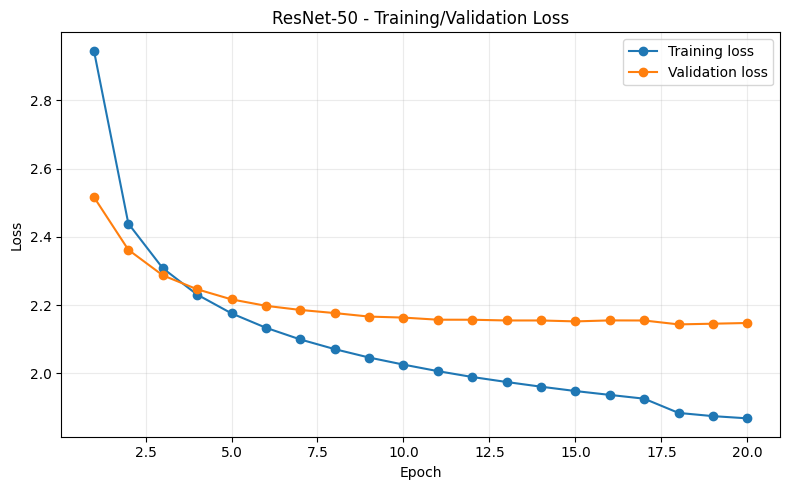

Đã lưu: /kaggle/working/MSCOCO_W3/figures/resnet50_loss.png


Generating resnet50:   0%|          | 0/2500 [00:00<?, ?it/s]

Đã lưu: /kaggle/working/MSCOCO_W3/predictions/resnet50_beam_predictions.json
Số caption: 2500
Inference: 4.67 phút

KẾT QUẢ: ResNet-50
BLEU-1  : 0.735536
BLEU-4  : 0.298996
METEOR  : 0.500679
ROUGE-L : 0.537427
CIDEr   : 0.622449
Đã xóa feature cache local: resnet50

MODEL: EfficientNet-B3
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 222MB/s]


Extracting efficientnet_b3:   0%|          | 0/1927 [00:00<?, ?it/s]

...

  0%|          | 0/196 [00:00<?, ?it/s]

[efficientnet_b3] Epoch 19/20 | train=1.8903 | val=2.1504 | lr=2.50e-05 | time=5.01 min


  0%|          | 0/9247 [00:00<?, ?it/s]

  0%|          | 0/196 [00:00<?, ?it/s]

[efficientnet_b3] Epoch 20/20 | train=1.8682 | val=2.1466 | lr=2.50e-05 | time=5.00 min
  -> Saved best: /kaggle/working/MSCOCO_W3/checkpoints/efficientnet_b3_best.pth


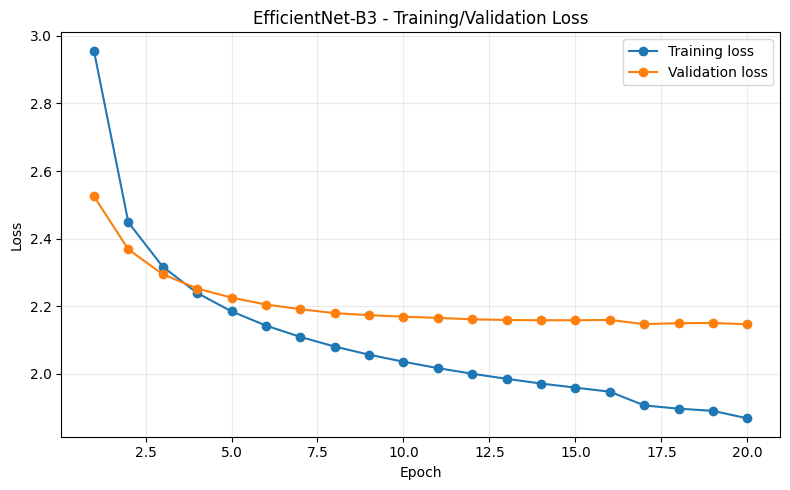

Đã lưu: /kaggle/working/MSCOCO_W3/figures/efficientnet_b3_loss.png


Generating efficientnet_b3:   0%|          | 0/2500 [00:00<?, ?it/s]

Đã lưu: /kaggle/working/MSCOCO_W3/predictions/efficientnet_b3_beam_predictions.json
Số caption: 2500
Inference: 4.62 phút

KẾT QUẢ: EfficientNet-B3
BLEU-1  : 0.738291
BLEU-4  : 0.313754
METEOR  : 0.504792
ROUGE-L : 0.543513
CIDEr   : 0.655283
Đã xóa feature cache local: efficientnet_b3

MODEL: ViT-B/16
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 226MB/s] 


Extracting vit_b_16:   0%|          | 0/1927 [00:00<?, ?it/s]

...

  0%|          | 0/196 [00:00<?, ?it/s]

[vit_b_16] Epoch 19/20 | train=1.9425 | val=2.1644 | lr=5.00e-05 | time=5.15 min


  0%|          | 0/9247 [00:00<?, ?it/s]

  0%|          | 0/196 [00:00<?, ?it/s]

[vit_b_16] Epoch 20/20 | train=1.9037 | val=2.1540 | lr=5.00e-05 | time=5.05 min
  -> Saved best: /kaggle/working/MSCOCO_W3/checkpoints/vit_b_16_best.pth


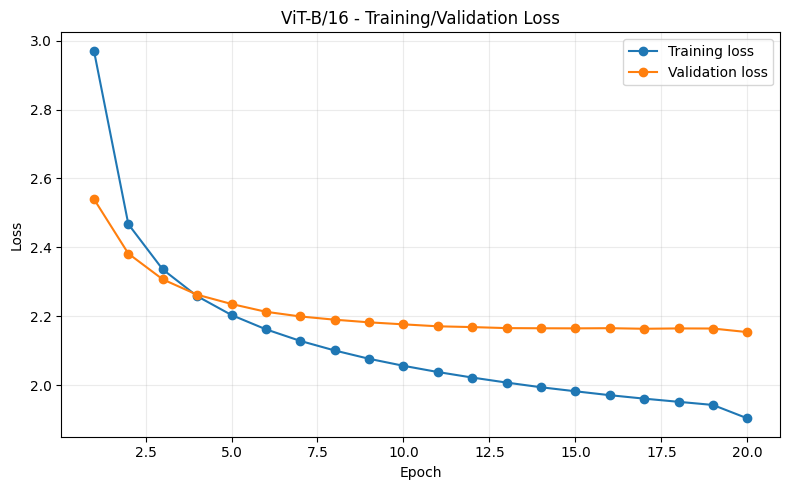

Đã lưu: /kaggle/working/MSCOCO_W3/figures/vit_b_16_loss.png


Generating vit_b_16:   0%|          | 0/2500 [00:00<?, ?it/s]

Đã lưu: /kaggle/working/MSCOCO_W3/predictions/vit_b_16_beam_predictions.json
Số caption: 2500
Inference: 4.60 phút

KẾT QUẢ: ViT-B/16
BLEU-1  : 0.723077
BLEU-4  : 0.289406
METEOR  : 0.488891
ROUGE-L : 0.528188
CIDEr   : 0.609298
Đã xóa feature cache local: vit_b_16

MODEL: CLIP-ViT-B/16


100%|████████████████████████████████████████| 335M/335M [00:03<00:00, 100MiB/s]


Extracting clip_vit_b16:   0%|          | 0/1927 [00:00<?, ?it/s]

...

  0%|          | 0/196 [00:00<?, ?it/s]

[clip_vit_b16] Epoch 19/20 | train=1.8330 | val=2.0179 | lr=5.00e-05 | time=4.97 min


  0%|          | 0/9247 [00:00<?, ?it/s]

  0%|          | 0/196 [00:00<?, ?it/s]

[clip_vit_b16] Epoch 20/20 | train=1.7965 | val=2.0061 | lr=5.00e-05 | time=4.97 min
  -> Saved best: /kaggle/working/MSCOCO_W3/checkpoints/clip_vit_b16_best.pth


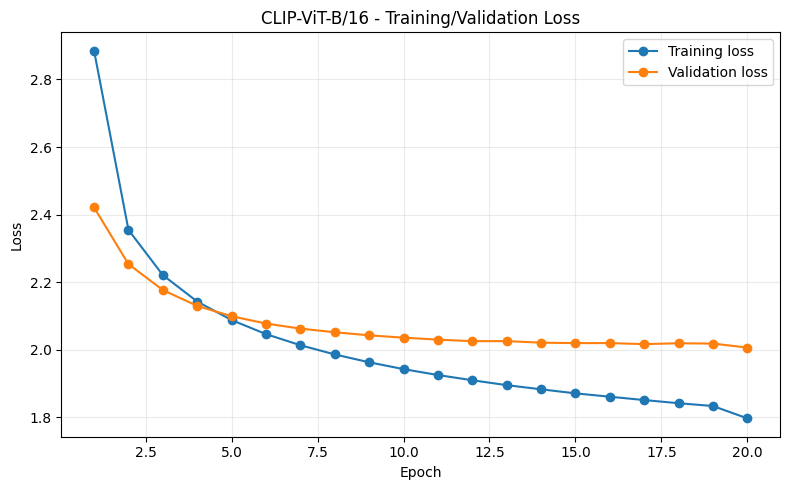

Đã lưu: /kaggle/working/MSCOCO_W3/figures/clip_vit_b16_loss.png


Generating clip_vit_b16:   0%|          | 0/2500 [00:00<?, ?it/s]

Đã lưu: /kaggle/working/MSCOCO_W3/predictions/clip_vit_b16_beam_predictions.json
Số caption: 2500
Inference: 4.52 phút

KẾT QUẢ: CLIP-ViT-B/16
BLEU-1  : 0.770744
BLEU-4  : 0.343782
METEOR  : 0.533806
ROUGE-L : 0.569550
CIDEr   : 0.732321
Đã xóa feature cache local: clip_vit_b16

HOÀN THÀNH: ResNet-50, EfficientNet-B3, ViT-B/16, CLIP-ViT-B/16


In [ ]:
# training_summaries = []
# metric_summaries = []
training_csv = REPORT_DIR / "training_summary.csv"
metrics_csv = REPORT_DIR / "test_metrics.csv"

if training_csv.exists():
    training_summaries = pd.read_csv(training_csv).to_dict("records")
    print("Đã nạp kết quả training cũ:", len(training_summaries))
else:
    training_summaries = []

if metrics_csv.exists():
    metric_summaries = pd.read_csv(metrics_csv).to_dict("records")
    print("Đã nạp kết quả metrics cũ:", len(metric_summaries))
else:
    metric_summaries = []
for MODEL_TO_RUN in MODELS_TO_RUN:
    print("\n" + "=" * 80)
    print("MODEL:", MODEL_DISPLAY_NAMES[MODEL_TO_RUN])
    print("=" * 80)

    feature_pack = extract_and_cache_features(
        MODEL_TO_RUN,
        batch_size=FEATURE_BATCH_SIZE,
        force_extract=False,
    )

    train_loader, val_loader = create_caption_loaders(
        feature_pack,
        batch_size=CAPTION_BATCH_SIZE,
    )

    train_summary, history, checkpoint_path = train_model(
        model_name=MODEL_TO_RUN,
        feature_pack=feature_pack,
        train_loader=train_loader,
        val_loader=val_loader,
        max_epochs=MAX_EPOCHS,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        early_stopping_patience=EARLY_STOPPING_PATIENCE,
    )

    training_summaries.append(train_summary)
    save_loss_figure(MODEL_TO_RUN, history)

    del train_loader, val_loader
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    prediction_payload = generate_test_predictions(
        model_name=MODEL_TO_RUN,
        feature_pack=feature_pack,
        method=DECODING_METHOD,
        beam_size=BEAM_SIZE,
    )

    metrics = evaluate_predictions(prediction_payload)
    metric_summaries.append(metrics)

    print("\nKẾT QUẢ:", MODEL_DISPLAY_NAMES[MODEL_TO_RUN])
    for key in ["BLEU-1", "BLEU-4", "METEOR", "ROUGE-L", "CIDEr"]:
        print(f"{key:8s}: {metrics[key]:.6f}")

    pd.DataFrame(training_summaries).to_csv(
        REPORT_DIR / "training_summary.csv",
        index=False,
        encoding="utf-8-sig",
    )

    pd.DataFrame(metric_summaries).to_csv(
        REPORT_DIR / "test_metrics.csv",
        index=False,
        encoding="utf-8-sig",
    )

    if DELETE_FEATURE_CACHE_AFTER_MODEL:
        feature_file = Path(feature_pack["feature_path"])
        meta_file = Path(feature_pack["meta_path"])

        if feature_file.exists():
            feature_file.unlink()

        if meta_file.exists():
            meta_file.unlink()

        print("Đã xóa feature cache local:", MODEL_TO_RUN)

    del feature_pack, prediction_payload
    gc.collect()

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

# print("\nHOÀN THÀNH 4 MÔ HÌNH.")
print("\nHOÀN THÀNH:", ", ".join(
    MODEL_DISPLAY_NAMES[m] for m in MODELS_TO_RUN
))

# 19. Bảng kết quả

In [ ]:
training_df = pd.read_csv(REPORT_DIR / "training_summary.csv")
metrics_df = pd.read_csv(REPORT_DIR / "test_metrics.csv")

print("=== KẾT QUẢ HUẤN LUYỆN ===")
display(
    training_df[
        [
            "Mô hình",
            "Epoch tốt nhất",
            "Training loss tại epoch tốt nhất",
            "Validation loss tại epoch tốt nhất",
            "Thời gian huấn luyện",
        ]
    ]
)

print("\n=== KẾT QUẢ TẬP KIỂM THỬ ===")
display(
    metrics_df[
        [
            "Mô hình",
            "BLEU-1",
            "BLEU-4",
            "METEOR",
            "ROUGE-L",
            "CIDEr",
        ]
    ]
)

best_by_cider = metrics_df.sort_values("CIDEr", ascending=False).iloc[0]
fastest = training_df.sort_values("Thời gian huấn luyện (giây)").iloc[0]

print("\nMô hình CIDEr tốt nhất:", best_by_cider["Mô hình"])
print("Mô hình huấn luyện nhanh nhất:", fastest["Mô hình"])

=== KẾT QUẢ HUẤN LUYỆN ===


,Mô hình,Epoch tốt nhất,Training loss tại epoch tốt nhất,Validation loss tại epoch tốt nhất,Thời gian huấn luyện
0,ResNet-50,18,1.884281,2.143660,1.69 giờ
1,EfficientNet-B3,20,1.868167,2.146581,1.68 giờ
2,ViT-B/16,20,1.903652,2.153965,1.67 giờ
3,CLIP-ViT-B/16,20,1.796505,2.006072,1.66 giờ



=== KẾT QUẢ TẬP KIỂM THỬ ===


,Mô hình,BLEU-1,BLEU-4,METEOR,ROUGE-L,CIDEr
0,ResNet-50,0.735536,0.298996,0.500679,0.537427,0.622449
1,EfficientNet-B3,0.738291,0.313754,0.504792,0.543513,0.655283
2,ViT-B/16,0.723077,0.289406,0.488891,0.528188,0.609298
3,CLIP-ViT-B/16,0.770744,0.343782,0.533806,0.569550,0.732321



Mô hình CIDEr tốt nhất: CLIP-ViT-B/16
Mô hình huấn luyện nhanh nhất: CLIP-ViT-B/16


# 20. Biểu đồ so sánh

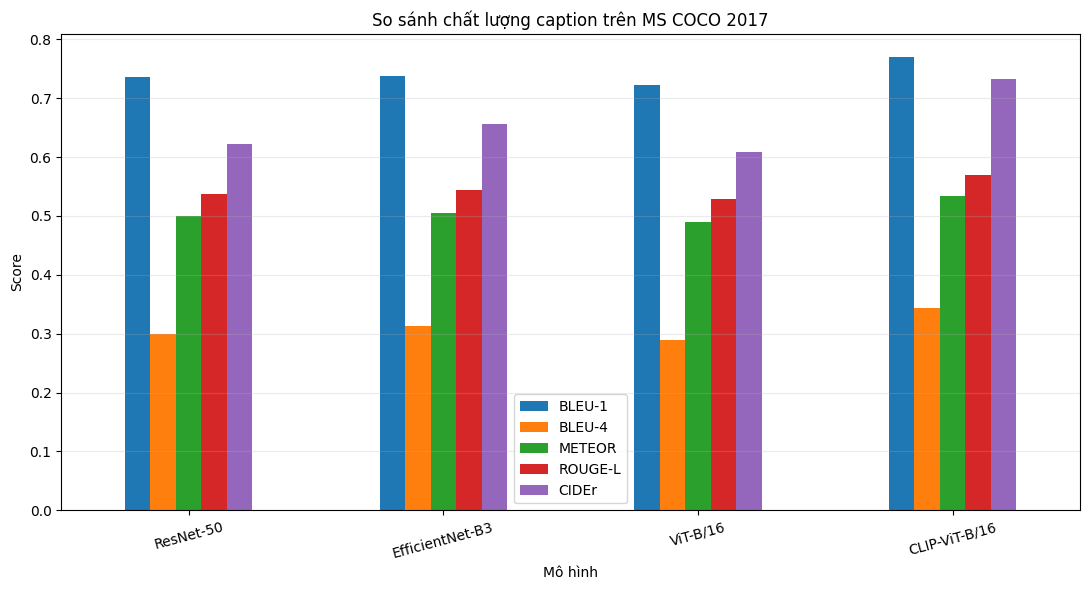

Đã lưu: /kaggle/working/MSCOCO_W3/figures/comparison_metrics.png


In [ ]:
metric_columns = ["BLEU-1", "BLEU-4", "METEOR", "ROUGE-L", "CIDEr"]

ax = metrics_df.set_index("Mô hình")[metric_columns].plot(
    kind="bar",
    figsize=(11, 6),
)

ax.set_title("So sánh chất lượng caption trên MS COCO 2017")
ax.set_xlabel("Mô hình")
ax.set_ylabel("Score")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=15)
plt.tight_layout()

comparison_path = FIGURE_DIR / "comparison_metrics.png"
plt.savefig(comparison_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

print("Đã lưu:", comparison_path)

# 21. Chọn tự động 3 trường hợp caption để phân tích

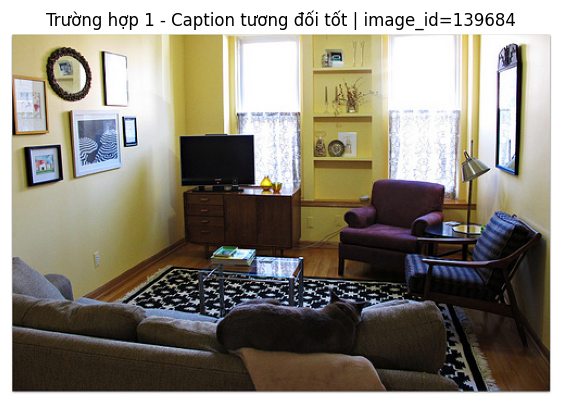

Caption tham chiếu:
  1. A living room filled with furniture and a flat screen tv.
  2. A living room with yellow walls and a black and white area rug.
  3. A cat is perched on the back of a sofa in a multi colored room.
  4. A living room with walls painted beige and furnishings and accents in shades of blue and purple.
  5. a living room witj a couch some chairs and a tv

Caption 4 mô hình:
  ResNet-50: a living room filled with furniture and a flat screen tv .
  EfficientNet-B3: a living room filled with furniture and a flat screen tv .
  ViT-B/16: a living room filled with furniture and a flat screen tv .
  CLIP-ViT-B/16: a living room filled with furniture and a flat screen tv .



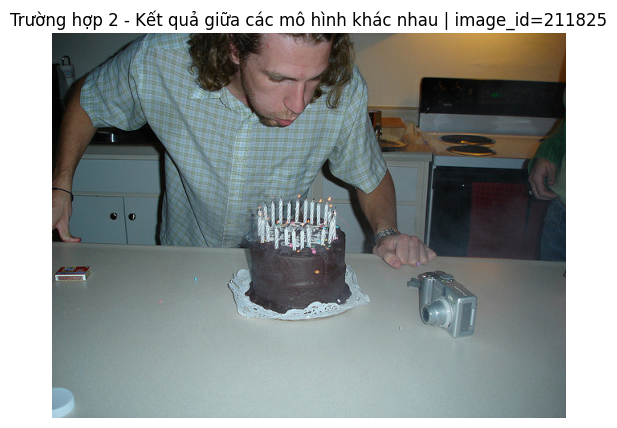

Caption tham chiếu:
  1. A man blowing out candles on a cake.
  2. A man blowing out a birthday cake with many candles.
  3. A man blowing out candles on a cake.
  4. A man blowing out candles on a cake
  5. Man blowing out white candles on top of a brown cake.

Caption 4 mô hình:
  ResNet-50: a man blowing out candles on a cake .
  EfficientNet-B3: a man blowing out candles on a cake .
  ViT-B/16: a man sitting at a table with a cake .
  CLIP-ViT-B/16: a man holding a cake with lit candles on it .



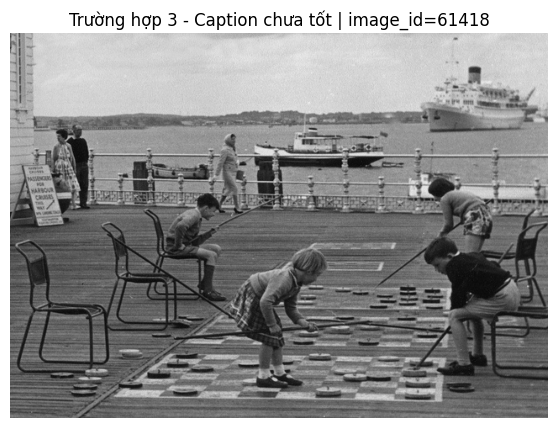

Caption tham chiếu:
  1. Several children attentively play a game of curling together.
  2. Several children playing a game together outside with boats in the background.
  3. Young children playing game on wooden deck surface.
  4. a couple of kids playing a game of checkers.
  5. some kids playing with some large checkerboards painted on the ground

Caption 4 mô hình:
  ResNet-50: a black and white photo of a skateboarder doing a trick
  EfficientNet-B3: a black and white photo of a man on a skateboard .
  ViT-B/16: a black and white photo of a person sitting on a bench .
  CLIP-ViT-B/16: a black and white photo of people on a dock .
Đã lưu: /kaggle/working/MSCOCO_W3/report_ready/caption_analysis_examples.json


In [ ]:
def load_prediction_map(model_name):
    path = PREDICTION_DIR / f"{model_name}_{DECODING_METHOD}_predictions.json"

    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)["predictions"]

all_predictions = {
    model_name: load_prediction_map(model_name)
    for model_name in MODEL_NAMES
}

smooth = SmoothingFunction().method1
analysis_rows = []

for image_id in map(str, test_image_ids):
    refs = TEST_REFERENCES[image_id]
    refs_tok = [basic_tokenize(ref) for ref in refs]

    scores = []
    for model_name in MODEL_NAMES:
        pred = all_predictions[model_name][image_id]

        score = sentence_bleu(
            refs_tok,
            basic_tokenize(pred),
            weights=(0.25, 0.25, 0.25, 0.25),
            smoothing_function=smooth,
        )

        scores.append(float(score))

    scores = np.asarray(scores, dtype=float)

    analysis_rows.append(
        {
            "image_id": image_id,
            "mean_bleu4": float(scores.mean()),
            "std_bleu4": float(scores.std()),
        }
    )

analysis_df = pd.DataFrame(analysis_rows)

good_id = analysis_df.sort_values(
    "mean_bleu4",
    ascending=False,
).iloc[0]["image_id"]

different_id = (
    analysis_df[analysis_df["image_id"] != good_id]
    .sort_values("std_bleu4", ascending=False)
    .iloc[0]["image_id"]
)

bad_id = (
    analysis_df[
        ~analysis_df["image_id"].isin([good_id, different_id])
    ]
    .sort_values("mean_bleu4", ascending=True)
    .iloc[0]["image_id"]
)

selected_cases = {
    "Trường hợp 1 - Caption tương đối tốt": good_id,
    "Trường hợp 2 - Kết quả giữa các mô hình khác nhau": different_id,
    "Trường hợp 3 - Caption chưa tốt": bad_id,
}

def show_case(title, image_id):
    image_id_int = int(image_id)
    image_path = VAL_IMAGE_DIR / coco_val_image_info[image_id_int]

    image = Image.open(image_path).convert("RGB")
    plt.figure(figsize=(7, 5))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"{title} | image_id={image_id}")
    plt.show()

    print("Caption tham chiếu:")
    for i, ref in enumerate(TEST_REFERENCES[str(image_id)], 1):
        print(f"  {i}. {ref}")

    print("\nCaption 4 mô hình:")
    for model_name in MODEL_NAMES:
        print(
            f"  {MODEL_DISPLAY_NAMES[model_name]}: "
            f"{all_predictions[model_name][str(image_id)]}"
        )

for title, image_id in selected_cases.items():
    print("\n" + "=" * 100)
    show_case(title, image_id)

analysis_output = {
    title: {
        "image_id": str(image_id),
        "references": TEST_REFERENCES[str(image_id)],
        "predictions": {
            MODEL_DISPLAY_NAMES[model_name]:
                all_predictions[model_name][str(image_id)]
            for model_name in MODEL_NAMES
        },
    }
    for title, image_id in selected_cases.items()
}

with open(
    REPORT_DIR / "caption_analysis_examples.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(analysis_output, f, ensure_ascii=False, indent=2)

print("Đã lưu:", REPORT_DIR / "caption_analysis_examples.json")

# 22. Xuất cấu hình

In [ ]:
experiment_config = {
    "dataset": "MS COCO 2017",
    "kaggle_dataset": KAGGLE_DATASET_HANDLE,
    "seed": SEED,
    "train_images": len(train_image_ids),
    "validation_images": len(validation_image_ids),
    "test_images": len(test_image_ids),
    "train_caption_samples": n_train_caption_samples,
    "validation_caption_samples": n_val_caption_samples,
    "vocabulary_size": VOCAB_SIZE,
    "min_freq": MIN_FREQ,
    "max_len": MAX_LEN,
    "feature_batch_size": FEATURE_BATCH_SIZE,
    "caption_batch_size": CAPTION_BATCH_SIZE,
    "max_epochs": MAX_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "visual_encoder": "Frozen / cached features",
    "decoder_layers": NUM_LAYERS,
    "d_model": D_MODEL,
    "attention_heads": NHEAD,
    "dim_feedforward": DIM_FEEDFORWARD,
    "dropout": DROPOUT,
    "decoding_method": DECODING_METHOD,
    "beam_size": BEAM_SIZE,
    "length_penalty_alpha": LENGTH_PENALTY_ALPHA,
    "models": MODEL_DISPLAY_NAMES,
    "device": str(DEVICE),
    "gpu": torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else None,
    "pytorch_version": torch.__version__,
    "torchvision_version": torchvision.__version__,
}

with open(
    REPORT_DIR / "experiment_config.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(experiment_config, f, ensure_ascii=False, indent=2)

print(json.dumps(experiment_config, ensure_ascii=False, indent=2))

{
  "dataset": "MS COCO 2017",
  "kaggle_dataset": "sabahesaraki/2017-2017",
  "seed": 42,
  "train_images": 118287,
  "validation_images": 2500,
  "test_images": 2500,
  "train_caption_samples": 591753,
  "validation_caption_samples": 12505,
  "vocabulary_size": 10312,
  "min_freq": 5,
  "max_len": 30,
  "feature_batch_size": 64,
  "caption_batch_size": 64,
  "max_epochs": 20,
  "learning_rate": 0.0001,
  "weight_decay": 0.0001,
  "visual_encoder": "Frozen / cached features",
  "decoder_layers": 3,
  "d_model": 256,
  "attention_heads": 8,
  "dim_feedforward": 1024,
  "dropout": 0.1,
  "decoding_method": "beam",
  "beam_size": 3,
  "length_penalty_alpha": 0.7,
  "models": {
    "resnet50": "ResNet-50",
    "efficientnet_b3": "EfficientNet-B3",
    "vit_b_16": "ViT-B/16",
    "clip_vit_b16": "CLIP-ViT-B/16"
  },
  "device": "cuda",
  "gpu": "Tesla T4",
  "pytorch_version": "2.10.0+cu128",
  "torchvision_version": "0.25.0+cu128"
}
